# 02b. ETF 시계열 하이브리드 모델 (Chronos + MTGNN)

**목표**: GAPS ETF 188개를 대상으로 Chronos+MTGNN 하이브리드 모델 학습
→ 카테고리별 월별 방향성 예측 `ai_pred_monthly.parquet` 생성

| 모듈 | 역할 |
|------|------|
| **Chronos T5 Encoder** | Close price → 시계열 temporal 임베딩 (512-dim) |
| **MTGNN Adaptive Graph** | 20개 기술지표 × 학습된 인접 행렬 → 피처 간 그래프 임베딩 |
| **Fusion MLP** | 두 임베딩 결합 → 1개월 수익률 예측 |

**선행 노트북**: `01_collect_etf_data_colab.ipynb` 실행 완료 필수  
**출력**: `ai_pred_monthly.parquet` — 월별 10개 카테고리 방향성 예측 (1=상승, -1=하락)  
**다음 노트북**: `04_rl_portfolio_agent.ipynb` (ai_pred 슬롯에 주입)

```
졸업 프로젝트 모델 (KOSPI 781종목)        GAPS용 모델 (ETF 188개)
  sequences.h5  →  ChronosMTGNN          etf_ohlcv_indicators.parquet → ChronosMTGNN
  출력: rl_embeddings.h5 (종목×날짜)       출력: ai_pred_monthly.parquet (월×카테고리)
```

**아키텍처 변경 없음**: 피처 구조(20개)가 동일해 모델 구조를 그대로 재사용

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q chronos-forecasting einops pyarrow tqdm

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.0 MB/s eta 0:00:00


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from pathlib import Path
import gc

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
DRIVE_ROOT = Path('/content/drive/MyDrive/졸업프로젝트/GAPS_대회')
DATA_DIR   = DRIVE_ROOT / 'data'
MODEL_DIR  = DRIVE_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ETF_PARQUET  = DATA_DIR / 'etf_ohlcv_indicators.parquet'  # 01 노트북 출력
EMB_CACHE    = DATA_DIR / 'etf_chronos_embs.npz'
OUTPUT_PATH  = DATA_DIR / 'ai_pred_monthly.parquet'       # 이 노트북 출력

# ── 하이퍼파라미터 ──────────────────────────────────────────────────────────────
SEQ_LEN     = 60    # 입력 lookback (영업일 기준 ~3개월)
PRED_DAYS   = 21    # 예측 구간 (~1개월, 영업일 기준)
N_FEATURES  = 20    # 졸업 프로젝트와 동일한 피처 수
BATCH_SIZE  = 128
LR          = 3e-4
EPOCHS      = 15
PATIENCE    = 3
DROPOUT     = 0.1
CHRONOS_DIM = 512   # chronos-t5-small encoder hidden dim

# ── 카테고리 정의 (04 노트북과 동일) ───────────────────────────────────────────
CATEGORIES = [
    'fx_commodity',
    'overseas_index',
    'overseas_sector',
    'domestic_index',
    'domestic_sector',
    'mmf_ultrashort',
    'overseas_bond_corp',
    'overseas_bond',
    'domestic_bond_corp',
    'domestic_bond',
]

# ── 피처 순서 (graduates project와 동일) ───────────────────────────────────────
FEATURE_COLS = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'SMA_20', 'SMA_60', 'EMA_12', 'EMA_26',
    'MACD', 'MACD_signal', 'MACD_hist',
    'RSI_14', 'BB_upper', 'BB_lower', 'BB_width',
    'Volume_ratio', 'Return_1d', 'Volatility_20d', 'ATR_14',
]

print(f'피처 수: {len(FEATURE_COLS)} (N_FEATURES={N_FEATURES})')
assert len(FEATURE_COLS) == N_FEATURES

Device: cuda
피처 수: 20 (N_FEATURES=20)


## 1. 데이터 로드 및 시퀀스 생성

In [10]:
print('ETF 데이터 로드 중...')
raw_df = pd.read_parquet(ETF_PARQUET)
raw_df['Date'] = pd.to_datetime(raw_df['Date'])
raw_df = raw_df.sort_values(['ticker', 'Date']).reset_index(drop=True)

# ticker → category 매핑
ticker_to_cat = raw_df[['ticker', 'category']].drop_duplicates().set_index('ticker')['category'].to_dict()

print(f'ETF 수: {raw_df["ticker"].nunique()}')
print(f'기간: {raw_df["Date"].min().date()} ~ {raw_df["Date"].max().date()}')
print(f'카테고리 분포:')
print(raw_df.groupby('category')['ticker'].nunique().sort_values(ascending=False))

ETF 데이터 로드 중...
ETF 수: 188
기간: 2019-01-02 ~ 2026-05-26
카테고리 분포:
category
overseas_index        47
domestic_sector       36
overseas_sector       31
domestic_index        17
domestic_bond         12
overseas_bond         11
mmf_ultrashort        11
domestic_bond_corp     9
fx_commodity           7
overseas_bond_corp     7
Name: ticker, dtype: int64


In [ ]:
def make_sequences(df_ticker: pd.DataFrame, seq_len: int, pred_days: int):
    """
    단일 ETF 데이터프레임 → (X_flat, y_ret, y_dir) 시퀀스 생성
    RevIN: 각 윈도우를 독립적으로 정규화 (mean/std 기준)
    """
    feat = df_ticker[FEATURE_COLS].values.astype(np.float32)  # (T, 20)
    close = df_ticker['Close'].values.astype(np.float32)       # (T,)
    T = len(feat)

    X_list, y_ret_list, y_dir_list = [], [], []

    for i in range(T - seq_len - pred_days + 1):
        window = feat[i : i + seq_len].copy()          # (60, 20)
        future_close = close[i + seq_len : i + seq_len + pred_days]

        if np.isnan(window).any() or np.isnan(future_close).any():
            continue

        # RevIN: 윈도우별 정규화
        mu  = window.mean(axis=0, keepdims=True)
        std = window.std(axis=0, keepdims=True) + 1e-8
        window = (window - mu) / std

        ret = (future_close[-1] - close[i + seq_len - 1]) / (close[i + seq_len - 1] + 1e-8)
        X_list.append(window)
        y_ret_list.append(ret)
        y_dir_list.append(1.0 if ret > 0 else 0.0)

    if not X_list:
        return None

    return (
        np.stack(X_list).astype(np.float32),
        np.array(y_ret_list, dtype=np.float32),
        np.array(y_dir_list, dtype=np.float32),
    )


# ── 학습 분할 (실전 예측 모드: 가용 데이터 전부 학습, val/early stopping 없음) ─
# val window가 1주일이면 SEQ_LEN(60)+PRED_DAYS(21)=81일 미만이라 시퀀스 생성 불가
# → 고정 epoch(EPOCHS)으로 학습, 마지막 epoch 모델 저장
TRAIN_END = '2026-06-12'   # 가용한 모든 데이터로 학습

splits = {'train': []}
meta   = []

tickers = raw_df['ticker'].unique()

for ticker in tqdm(tickers, desc='시퀀스 생성'):
    sub = raw_df[raw_df['ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    cat = ticker_to_cat.get(ticker, 'unknown')

    mask = (sub['Date'] >= '2021-01-01') & (sub['Date'] <= TRAIN_END)
    df_s = sub[mask].reset_index(drop=True)

    result = make_sequences(df_s, SEQ_LEN, PRED_DAYS)
    if result is None:
        continue

    X, y_ret, y_dir = result
    splits['train'].append((X, y_ret, y_dir))

    for j in range(len(X)):
        date_idx = df_s['Date'].iloc[SEQ_LEN + j - 1]
        meta.append({'split': 'train', 'ticker': ticker, 'category': cat, 'date': date_idx})


def concat_splits(split_list):
    if not split_list:
        return (
            np.zeros((0, SEQ_LEN, N_FEATURES), dtype=np.float32),
            np.zeros(0, dtype=np.float32),
            np.zeros(0, dtype=np.float32),
        )
    Xs     = np.concatenate([s[0] for s in split_list], axis=0)
    y_rets = np.concatenate([s[1] for s in split_list], axis=0)
    y_dirs = np.concatenate([s[2] for s in split_list], axis=0)
    return Xs, y_rets, y_dirs

X_tr, yr_tr, yd_tr = concat_splits(splits['train'])
meta_df = pd.DataFrame(meta)

print(f'train: {X_tr.shape}')
print(f'상승 비율 — train: {yd_tr.mean():.3f}')

## 2. Chronos 임베딩 추출 (최초 1회 후 캐시)

In [ ]:
from chronos import ChronosPipeline

gc.collect()
torch.cuda.empty_cache()

pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print('Chronos 로드 완료')


@torch.no_grad()
def extract_chronos_embs(close_prices_np, batch_size=256, desc=''):
    """close_prices_np: (N, seq_len) float32 → (N, CHRONOS_DIM) embeddings"""
    tokenizer = pipeline.tokenizer
    encoder   = pipeline.model.model.encoder
    all_embs  = []
    for i in tqdm(range(0, len(close_prices_np), batch_size), desc=desc):
        batch = close_prices_np[i : i + batch_size]
        # tokenizer boundaries는 CPU에 있으므로 입력도 CPU로 넘긴 뒤 결과만 CUDA로 이동
        tokens, attn_mask, _ = tokenizer.context_input_transform(
            torch.from_numpy(batch)  # CPU
        )
        tokens     = tokens.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        out = encoder(input_ids=tokens, attention_mask=attn_mask)
        emb = (out.last_hidden_state * attn_mask.unsqueeze(-1)).sum(1) / attn_mask.sum(1, keepdim=True)
        all_embs.append(emb.cpu().float().numpy())
    return np.concatenate(all_embs, axis=0)

In [ ]:
%%time
# ⚠️ split이 바뀌었으므로 Drive에서 etf_chronos_embs.npz 삭제 후 실행
if EMB_CACHE.exists():
    cached = np.load(EMB_CACHE)
    tr_emb = cached['train']
    print(f'캐시 로드: train={tr_emb.shape}')
else:
    print('Chronos 임베딩 추출 (최초 1회)...')
    tr_emb = extract_chronos_embs(X_tr[:, :, 0], desc='train')
    np.savez_compressed(EMB_CACHE, train=tr_emb)
    print(f'캐시 저장: {EMB_CACHE}')

## 3. ChronosMTGNN 모델 정의

졸업 프로젝트 KOSPI 모델과 **동일한 아키텍처** — 피처 구조(20개)가 같으므로 변경 없음

```
Chronos T5 Encoder → mean pool → Linear → (B, 64) ─┐
                                                      ├→ Fusion → 256 → 64 → 1 (수익률)
MTGNN Encoder → AdaptGraph+GatedTCN → (B, 20×64) ──┘
```

In [14]:
class AdaptiveGraphLearner(nn.Module):
    def __init__(self, n_nodes, emb_dim=10):
        super().__init__()
        self.E1 = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)
        self.E2 = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)

    def forward(self):
        return torch.softmax(torch.relu(self.E1 @ self.E2.T), dim=-1)


class GatedTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.filter_conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.gate_conv   = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.res         = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        f = torch.tanh(self.filter_conv(x)[..., :x.size(-1)])
        g = torch.sigmoid(self.gate_conv(x)[..., :x.size(-1)])
        return f * g + self.res(x)


class MTGNNEncoder(nn.Module):
    def __init__(self, seq_len, n_features, d_model=64, n_layers=3, dropout=0.1):
        super().__init__()
        self.graph   = AdaptiveGraphLearner(n_features)
        self.proj_in = nn.Linear(seq_len, d_model)
        self.tcn_layers = nn.ModuleList([
            GatedTCNBlock(d_model, d_model, dilation=2**i)
            for i in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.n_features = n_features
        self.d_model    = d_model

    def forward(self, x):
        # x: (B, seq_len, n_features) → treat features as nodes
        B = x.size(0)
        A = self.graph()                                      # (F, F)
        h = x.permute(0, 2, 1)                               # (B, F, T)
        h = self.proj_in(h)                                   # (B, F, d_model)
        h = h.reshape(B * self.n_features, self.d_model, 1)  # (B*F, d_model, 1)
        h = h.expand(-1, -1, self.n_features)                 # (B*F, d_model, F)
        for tcn in self.tcn_layers:
            h = self.dropout(tcn(h))
        h = h.mean(-1).reshape(B, self.n_features * self.d_model)  # (B, F*d)
        return h


class ChronosMTGNN(nn.Module):
    def __init__(self, seq_len, n_features, chronos_dim, d_model=64, n_layers=3, dropout=0.1):
        super().__init__()
        self.chronos_proj = nn.Sequential(
            nn.Linear(chronos_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.mtgnn = MTGNNEncoder(seq_len, n_features, d_model, n_layers, dropout)
        fusion_dim = d_model + n_features * d_model
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
        )
        self.head = nn.Linear(64, 1)

    def forward(self, x_flat, c_emb):
        ch = self.chronos_proj(c_emb)       # (B, 64)
        mg = self.mtgnn(x_flat)             # (B, F*64)
        fused = self.fusion(torch.cat([ch, mg], dim=-1))  # (B, 64)
        return self.head(fused).squeeze(-1)  # (B,)

    def get_embedding(self, x_flat, c_emb):
        """64-dim 임베딩 반환 (헤드 이전)"""
        ch = self.chronos_proj(c_emb)
        mg = self.mtgnn(x_flat)
        return self.fusion(torch.cat([ch, mg], dim=-1))


print('모델 정의 완료')

모델 정의 완료


## 4. 데이터셋 & 로더

In [ ]:
class ETFHybridDataset(Dataset):
    def __init__(self, X, y_ret, y_dir, chronos_embs):
        self.X    = torch.from_numpy(X)
        self.y    = torch.from_numpy(y_ret)
        self.embs = torch.from_numpy(chronos_embs.astype(np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.embs[i], self.y[i]


tr_ds = ETFHybridDataset(X_tr, yr_tr, yd_tr, tr_emb)
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f'DataLoader 준비 완료 — train: {len(tr_ds)}')

## 5. 학습 & 평가

In [ ]:
def compute_metrics(loader, model):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, emb, y in loader:
            x, emb = x.to(DEVICE), emb.to(DEVICE)
            out = model(x, emb).cpu().numpy()
            preds.append(out)
            targets.append(y.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    dir_acc  = ((preds > 0) == (targets > 0)).mean()
    spear, _ = spearmanr(targets, preds)
    mae      = np.abs(targets - preds).mean()
    return {'dir_acc': round(float(dir_acc), 4), 'spearman': round(float(spear), 4), 'mae': round(float(mae), 6)}


def train_model():
    model = ChronosMTGNN(SEQ_LEN, N_FEATURES, CHRONOS_DIM, d_model=64, n_layers=3, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.HuberLoss(delta=0.01)
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss = 0.0
        for x, emb, y in tqdm(tr_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
            x, emb, y = x.to(DEVICE), emb.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x, emb), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item()

        tr_loss /= len(tr_loader)
        scheduler.step()
        history.append({'epoch': epoch, 'tr_loss': tr_loss})
        print(f'Ep {epoch:02d} | tr_loss={tr_loss:.5f}')

    # val 없음 — 마지막 epoch 모델 저장
    torch.save(model.state_dict(), MODEL_DIR / 'etf_hybrid_best.pt')
    return model, history

In [17]:
%%time
gc.collect()
torch.cuda.empty_cache()

model, history = train_model()
print('학습 완료. 모델 저장: etf_hybrid_best.pt')

Epoch 1/15:   0%|          | 0/774 [00:00<?, ?it/s]

Ep 01 | tr_loss=0.00033 | va_loss=0.00038 | dir_acc=0.5768 | spearman=0.1032


Epoch 2/15:   0%|          | 0/774 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    Exception ignored in: if w.is_alive():
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040>   
  Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
 ^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^
^ ^ ^^ ^  
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  ^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
^^  ^ ^ ^  ^ ^ ^ ^ ^ 
^^  File "/u

Ep 02 | tr_loss=0.00027 | va_loss=0.00039 | dir_acc=0.5181 | spearman=0.0406


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040>    if w.is_alive():

  Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
       self._shutdown_workers()
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^
 ^^ ^ ^ ^ ^  ^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^  ^ ^ ^ ^ 
   File "/usr/li

Ep 03 | tr_loss=0.00024 | va_loss=0.00038 | dir_acc=0.5509 | spearman=0.1164


Epoch 4/15:   0%|          | 0/774 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d3f88128040> 
  Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      ^self._shutdown_workers()^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^  ^ ^ 
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ ^ ^ ^^  
   File "/usr/

Ep 04 | tr_loss=0.00021 | va_loss=0.00040 | dir_acc=0.5279 | spearman=0.0568
Early stopping at epoch 4
학습 완료. 모델 저장: etf_hybrid_best.pt
CPU times: user 1min 3s, sys: 4.5 s, total: 1min 7s
Wall time: 1min 21s


## 6. 테스트 평가 & 카테고리별 성능

In [ ]:
# 실전 예측 모드: val 없음 → train 성능으로 학습 확인
tr_metrics = compute_metrics(tr_loader, model)
print('=== Train 성능 (학습 수렴 확인용) ===')
print(f'  Directional Accuracy : {tr_metrics["dir_acc"]:.4f}')
print(f'  Spearman Correlation : {tr_metrics["spearman"]:.4f}')
print(f'  MAE                  : {tr_metrics["mae"]:.6f}')

In [ ]:
# 실전 예측 모드: test set 없음 → train 기준 카테고리별 성능 확인
model.eval()
tr_meta = meta_df.reset_index(drop=True)

all_preds = []
with torch.no_grad():
    for x, emb, _ in tr_loader:
        out = model(x.to(DEVICE), emb.to(DEVICE)).cpu().numpy()
        all_preds.append(out)
all_preds = np.concatenate(all_preds)

tr_meta = tr_meta.iloc[:len(all_preds)].copy()
tr_meta['pred_ret']   = all_preds
tr_meta['pred_dir']   = (all_preds > 0).astype(int)
tr_meta['actual_dir'] = (yd_tr[:len(all_preds)] > 0).astype(int)
tr_meta['correct']    = (tr_meta['pred_dir'] == tr_meta['actual_dir']).astype(int)

cat_acc = tr_meta.groupby('category')['correct'].mean().sort_values(ascending=False)
print('\n카테고리별 방향성 정확도 (train):')
print(cat_acc.to_string())

cat_acc.plot.bar(figsize=(10, 4), title='카테고리별 방향성 정확도', ylabel='Dir Acc', color='steelblue')
plt.axhline(0.5, color='red', linestyle='--', label='Random (0.5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'etf_hybrid_category_acc.png', dpi=150)
plt.show()

## 7. ai_pred_monthly 생성 → 04 노트북에 전달

`04_rl_portfolio_agent.ipynb`의 `ETFPortfolioEnv` State에 주입되는
`ai_pred` (10-dim)를 월별로 생성해 저장합니다.

**생성 방식**: 각 월말 기준으로 직전 60일 데이터로 추론 → ETF별 예측 수익률 → 카테고리 평균

In [ ]:
from chronos import ChronosPipeline

model.eval()

# 월말 날짜 목록
all_dates = pd.date_range('2021-01-01', raw_df['Date'].max(), freq='ME')

monthly_preds = {}  # {date: {category: mean_pred_ret}}

tokenizer = pipeline.tokenizer
encoder   = pipeline.model.model.encoder

for month_end in tqdm(all_dates, desc='월별 추론'):
    cat_preds = {cat: [] for cat in CATEGORIES}

    for ticker in tickers:
        sub = raw_df[(raw_df['ticker'] == ticker) & (raw_df['Date'] <= month_end)]
        if len(sub) < SEQ_LEN:
            continue

        window = sub[FEATURE_COLS].values[-SEQ_LEN:].astype(np.float32)  # (60, 20)
        if np.isnan(window).any():
            continue

        # RevIN
        mu  = window.mean(axis=0, keepdims=True)
        std = window.std(axis=0, keepdims=True) + 1e-8
        window_norm = (window - mu) / std

        x_t   = torch.from_numpy(window_norm).unsqueeze(0).to(DEVICE)  # (1, 60, 20)
        close = torch.from_numpy(window[:, 0]).unsqueeze(0)             # CPU

        with torch.no_grad():
            tokens, attn_mask, _ = tokenizer.context_input_transform(close)  # CPU
            tokens, attn_mask = tokens.to(DEVICE), attn_mask.to(DEVICE)
            enc_out = encoder(input_ids=tokens, attention_mask=attn_mask)
            emb = (enc_out.last_hidden_state * attn_mask.unsqueeze(-1)).sum(1) / attn_mask.sum(1, keepdim=True)
            pred = model(x_t, emb).item()

        cat = ticker_to_cat.get(ticker)
        if cat in cat_preds:
            cat_preds[cat].append(pred)

    monthly_preds[month_end] = {
        cat: np.mean(v) if v else 0.0
        for cat, v in cat_preds.items()
    }

# DataFrame으로 변환 (날짜 × 카테고리)
ai_pred_df = pd.DataFrame(monthly_preds).T[CATEGORIES]
ai_pred_df.index.name = 'date'

print(f'ai_pred 생성 완료: {ai_pred_df.shape}')
print(ai_pred_df.tail())

저장 완료: /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data/ai_pred_monthly.parquet
shape: (64, 10)  (월 × 10카테고리)


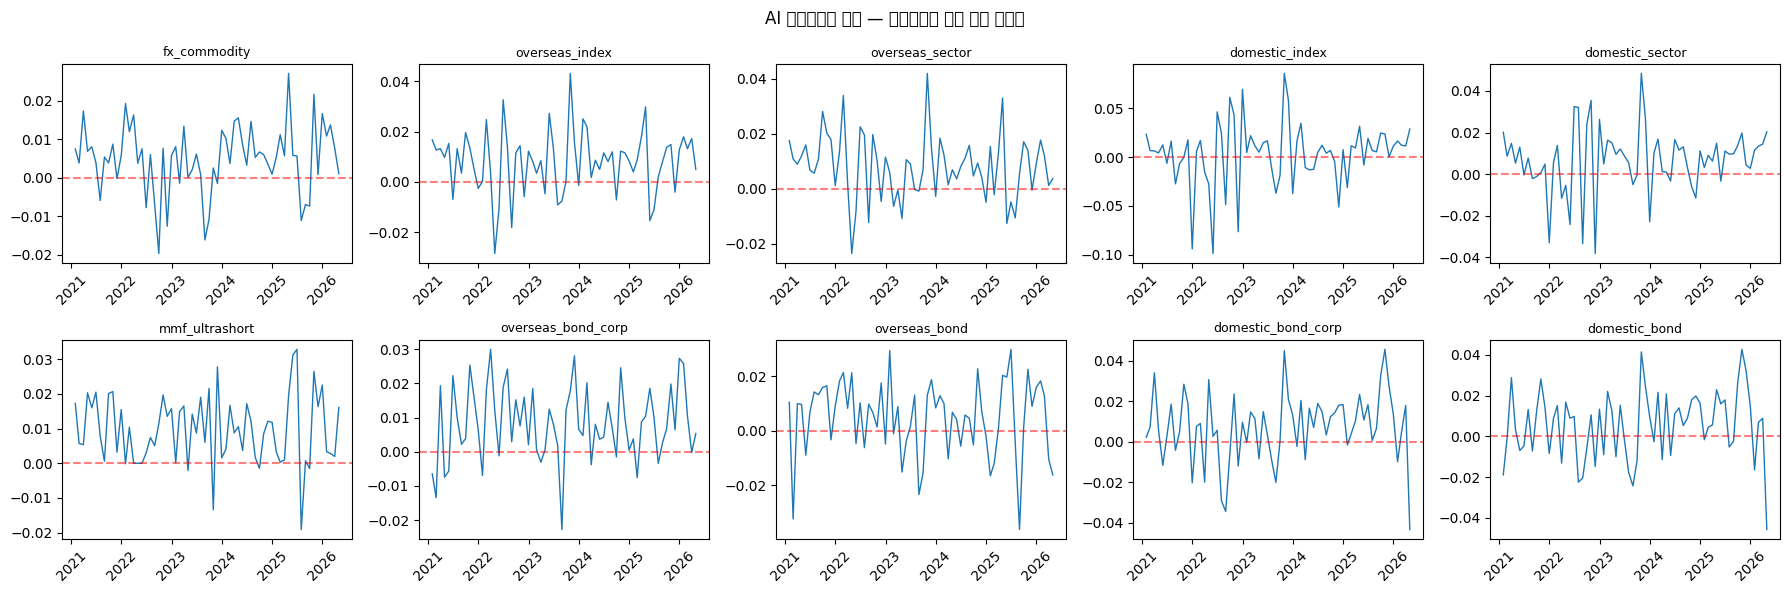


=== 요약 ===
파일: ai_pred_monthly.parquet
구조: (64, 10)  — 행=월말날짜, 열=10개 카테고리
값: 각 카테고리 내 ETF들의 평균 예측 수익률
활용: 04_rl_portfolio_agent.ipynb의 ai_pred 슬롯에 주입


In [22]:
ai_pred_df.to_parquet(OUTPUT_PATH)
print(f'저장 완료: {OUTPUT_PATH}')
print(f'shape: {ai_pred_df.shape}  (월 × 10카테고리)')

# 시각화
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, cat in zip(axes.flat, CATEGORIES):
    ax.plot(ai_pred_df.index, ai_pred_df[cat], linewidth=1)
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(cat, fontsize=9)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('AI 하이브리드 모델 — 카테고리별 월별 예측 수익률', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'ai_pred_monthly.png', dpi=150)
plt.show()

print('\n=== 요약 ===')
print(f'파일: ai_pred_monthly.parquet')
print(f'구조: {ai_pred_df.shape}  — 행=월말날짜, 열=10개 카테고리')
print(f'값: 각 카테고리 내 ETF들의 평균 예측 수익률')
print(f'활용: 04_rl_portfolio_agent.ipynb의 ai_pred 슬롯에 주입')

## 결과 요약

| 산출물 | 설명 | 활용 |
|--------|------|------|
| `etf_hybrid_best.pt` | 학습된 ChronosMTGNN 가중치 | 추후 추론 |
| `etf_chronos_embs.npz` | Chronos 임베딩 캐시 | 재학습 속도 개선 |
| `ai_pred_monthly.parquet` | 월별 10개 카테고리 예측 수익률 | **04 노트북 ai_pred 슬롯** |
| `etf_hybrid_category_acc.png` | 카테고리별 방향성 정확도 차트 | 보고서 |

**다음 단계**: `04_rl_portfolio_agent.ipynb` 실행 시
`ai_pred_monthly.parquet`를 로드해 `ETFPortfolioEnv`의 `ai_pred` 슬롯에 전달

```python
# 04 노트북에서 사용 방법
ai_pred_df = pd.read_parquet(DATA_DIR / 'ai_pred_monthly.parquet')
env = ETFPortfolioEnv(cat_ret, ai_pred=ai_pred_df)  # ai_pred 인자 추가 필요
```

## 8. ETF별 개별 예측 생성 (RL 실험용)

카테고리 평균 대신 ETF 각각의 예측 수익률을 저장합니다.

- **출력**: `ai_pred_etf_weekly.parquet` — (주 × ETF수)
- **활용**: RL 에이전트가 ETF 레벨 Action을 사용하는 경우

In [ ]:
# ── 기존 학습된 모델 로드 (Section 5 학습 스킵 시 여기서부터 실행) ─────────────
model = ChronosMTGNN(SEQ_LEN, N_FEATURES, CHRONOS_DIM, d_model=64, n_layers=3, dropout=DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(MODEL_DIR / 'etf_hybrid_best.pt', map_location=DEVICE))
model.eval()
print('모델 로드 완료:', MODEL_DIR / 'etf_hybrid_best.pt')

In [ ]:
OUTPUT_ETF_PATH     = DATA_DIR / 'ai_pred_etf_weekly.parquet'
OUTPUT_WEEKLY_PATH  = DATA_DIR / 'ai_pred_weekly.parquet'   # 05 노트북용 (카테고리별 주별)

model.eval()

# 주별 날짜 목록 (매주 금요일)
all_dates = pd.date_range('2021-01-01', raw_df['Date'].max(), freq='W-FRI')

etf_preds = {}  # {date: {ticker: pred_ret}}

tokenizer = pipeline.tokenizer
encoder   = pipeline.model.model.encoder

for week_end in tqdm(all_dates, desc='주별 ETF 개별 추론'):
    ticker_preds = {}

    for ticker in tickers:
        sub = raw_df[(raw_df['ticker'] == ticker) & (raw_df['Date'] <= week_end)]
        if len(sub) < SEQ_LEN:
            continue

        window = sub[FEATURE_COLS].values[-SEQ_LEN:].astype(np.float32)
        if np.isnan(window).any():
            continue

        # RevIN
        mu  = window.mean(axis=0, keepdims=True)
        std = window.std(axis=0, keepdims=True) + 1e-8
        window_norm = (window - mu) / std

        x_t   = torch.from_numpy(window_norm).unsqueeze(0).to(DEVICE)
        close = torch.from_numpy(window[:, 0]).unsqueeze(0)  # CPU

        with torch.no_grad():
            tokens, attn_mask, _ = tokenizer.context_input_transform(close)  # CPU
            tokens, attn_mask = tokens.to(DEVICE), attn_mask.to(DEVICE)
            enc_out = encoder(input_ids=tokens, attention_mask=attn_mask)
            emb = (enc_out.last_hidden_state * attn_mask.unsqueeze(-1)).sum(1) / attn_mask.sum(1, keepdim=True)
            pred = model(x_t, emb).item()

        ticker_preds[ticker] = pred

    etf_preds[week_end] = ticker_preds

# ── ETF별 저장 (ai_pred_etf_weekly.parquet) ──────────────────────────────────
ai_pred_etf_df = pd.DataFrame(etf_preds).T
ai_pred_etf_df.index.name = 'date'
ai_pred_etf_df = ai_pred_etf_df.fillna(0.0)

cat_map = pd.Series(ticker_to_cat)
multi_idx = pd.MultiIndex.from_arrays(
    [cat_map.reindex(ai_pred_etf_df.columns), ai_pred_etf_df.columns],
    names=['category', 'ticker']
)
ai_pred_etf_df.columns = multi_idx
ai_pred_etf_df = ai_pred_etf_df.sort_index(axis=1)

ai_pred_etf_df.to_parquet(OUTPUT_ETF_PATH)
print(f'ETF별 저장 완료: {OUTPUT_ETF_PATH}  {ai_pred_etf_df.shape}')

# ── 카테고리별 주별 평균 저장 (ai_pred_weekly.parquet) → 05 노트북용 ─────────
ai_pred_weekly = ai_pred_etf_df.groupby(level='category', axis=1).mean()
ai_pred_weekly = ai_pred_weekly.reindex(columns=CATEGORIES)
ai_pred_weekly.index.name = 'date'

ai_pred_weekly.to_parquet(OUTPUT_WEEKLY_PATH)
print(f'카테고리별 주별 저장 완료: {OUTPUT_WEEKLY_PATH}  {ai_pred_weekly.shape}')